In [45]:
from src.data import DataPipeline # Módulo para baixar e pré-processar os dados
from src.train import conv_rnn_training # Módulo para treinar modelos ConvRNN
from src.dataset import SARDataset # Módulo para criar datasets a partir dos dados pré-processados
from src.models import ConvGRURegressor, ConvLSTMRegressor # Módulo para definir modelos ConvRNN
from src.inference import load_weights, conv_rnn_predict, masked_mae, masked_rmse # Módulo para fazer inferência
import torch
import rasterio as rio
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import pickle as pkl
import numpy as np
import pandas as pd
import logging
from pathlib import Path
import re

In [46]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger(__name__)

Declaração de variáveis do ambiente:

In [47]:
# Diretórios e caminhos de arquivos
DATA_DIR = "data/preprocessed"
LABEL_PATH = "data/labels/sample_2018_2024_normalized.tif"
STATS_PATH = "data/aggregated/norm_stats.json"

# Diretórios e caminhos de arquivos para teste
TEST_DATA_DIR = "data/preprocessed_test"
TEST_LABEL_PATH = "data/labels/test_2018_2024_normalized.tif"
TEST_STATS_PATH = "data/aggregated/norm_stats_test.json"

# Diretórios para salvar pesos, logs e resultados
WEIGHTS_DIR = Path("checkpoints")
LOGS_DIR = Path("logs")
RESULTS_DIR = Path("results")

# Tamanho do patch e tamanho do batch
PATCH_SIZE = 128
BATCH_SIZE = 2

# Hiperparâmetros para grid search
ARCH = ["ConvGRU", "ConvLSTM"]
HIDDEN_CHANNELS = [16, 32]
LEARNING_RATE = [1e-3, 5e-4]
KERNEL_SIZE = [3, 5]

# Épocas de treinamento
EPOCHS = 50

# Constantes
YEAR_START = 2018
YEAR_END = 2024
HEAD_CHANNELS = [16]
VAL_FRACTION = 0.2
POS_WEIGHT = 3.26
INPUT_CHANNELS = 2
SEED = 0

Função para puxar e pré-processar dados. Busca de dados brutos pode ser ignorada se dados já estão presentes:

In [48]:
def fetch_train_data(skip_raw=True, skip_preproc=False):
    # Engenharia de dados: baixar, pré-processar e normalizar os dados
    pipeline = DataPipeline(
        label_path="data/labels/sample_2000_2024.tif",
        raw_path="data/raw/",
        preproc_path="data/preprocessed/",
        stats_path=STATS_PATH,
        year_start=YEAR_START,
        year_end=YEAR_END
    )
    if not skip_raw:
        pipeline.raw()
    if not skip_preproc:
        pipeline.preprocessed()
        pipeline.labels(outfile=f"data/labels/sample_{YEAR_START}_{YEAR_END}_normalized.tif")
        
fetch_train_data()

2026-09-01 02:59:21,473 | INFO | src.data | Preprocessing file 2018-01.VH ...
2026-09-01 02:59:21,932 | INFO | src.data | Preprocessing file 2018-01.VV ...
2026-09-01 02:59:22,240 | INFO | src.data | Preprocessing file 2018-02.VH ...
2026-09-01 02:59:22,518 | INFO | src.data | Preprocessing file 2018-02.VV ...
2026-09-01 02:59:22,808 | INFO | src.data | Preprocessing file 2018-03.VH ...
2026-09-01 02:59:23,089 | INFO | src.data | Preprocessing file 2018-03.VV ...
2026-09-01 02:59:23,377 | INFO | src.data | Preprocessing file 2018-04.VH ...
2026-09-01 02:59:23,697 | INFO | src.data | Preprocessing file 2018-04.VV ...
2026-09-01 02:59:23,973 | INFO | src.data | Preprocessing file 2018-05.VH ...
2026-09-01 02:59:24,257 | INFO | src.data | Preprocessing file 2018-05.VV ...
2026-09-01 02:59:24,533 | INFO | src.data | Preprocessing file 2018-06.VH ...
2026-09-01 02:59:24,826 | INFO | src.data | Preprocessing file 2018-06.VV ...
2026-09-01 02:59:25,108 | INFO | src.data | Preprocessing file 2

*Grid search* sobre os hiper-parâmetros declarados, totalizando 16 combinações em 50 épocas (~16h de treinamento em uma T4 Kaggle):

In [49]:
def train():
    
    # Loop de treinamento para cada combinação de hiperparâmetros
    logger.info("Procedimento de treinamento iniciado.")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        logger.info(f"Device: {torch.cuda.get_device_name(0)}")
        
    dataset = SARDataset(
        data_dir=DATA_DIR, 
        label_path=LABEL_PATH,
        stats_path=STATS_PATH,
        patch_size=PATCH_SIZE
    )

    n_val = max(1, int(len(dataset) * VAL_FRACTION))
    n_train = len(dataset) - n_val
    generator = torch.Generator().manual_seed(SEED)
    train_set, val_set = random_split(dataset, [n_train, n_val], generator=generator)
       
    WEIGHTS_DIR.mkdir(exist_ok=True)
    LOGS_DIR.mkdir(exist_ok=True)

    for arch in ARCH:
        for hidden in HIDDEN_CHANNELS:
            for kernel in KERNEL_SIZE:
                for lr in LEARNING_RATE:
                    weights_str = f"{arch}_" + f"hidden{hidden}-" + f"kernel{kernel}-" + f"lr{lr}".replace(".", "p")
                    weights_path = WEIGHTS_DIR / f"{weights_str}.pth"
                    history_path = LOGS_DIR / f"{weights_str}.parquet"
                    
                    if weights_path.exists():
                        logger.warning(f"Checkpoint de {weights_str} já existe. Pulando...")
                        continue
                    
                    logger.info(f"Começando arquitetura {weights_str}")
                    
                    history = conv_rnn_training(
                        input_channels=INPUT_CHANNELS,
                        kernel_size=kernel,
                        hidden_channels=hidden,
                        head_channels=HEAD_CHANNELS,
                        lrate=lr,
                        train_dataset=train_set,
                        val_dataset=val_set,
                        batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        pos_weight=POS_WEIGHT,
                        device=device,
                        weights_path=weights_path,
                        arch=arch,
                        patience=None
                    )
                    
                    history.to_parquet(history_path, index=False)
                
train()

2026-09-01 03:00:18,273 | INFO | __main__ | Procedimento de treinamento iniciado.
2026-09-01 03:00:18,310 | INFO | __main__ | Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU
2026-09-01 03:00:18,371 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel3-lr0p001 já existe. Pulando...
2026-09-01 03:00:18,372 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel3-lr0p0005 já existe. Pulando...
2026-09-01 03:00:18,373 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel5-lr0p001 já existe. Pulando...
2026-09-01 03:00:18,374 | WARNING | __main__ | Checkpoint de ConvGRU_hidden16-kernel5-lr0p0005 já existe. Pulando...
2026-09-01 03:00:18,376 | WARNING | __main__ | Checkpoint de ConvGRU_hidden32-kernel3-lr0p001 já existe. Pulando...
2026-09-01 03:00:18,379 | WARNING | __main__ | Checkpoint de ConvGRU_hidden32-kernel3-lr0p0005 já existe. Pulando...
2026-09-01 03:00:18,380 | WARNING | __main__ | Checkpoint de ConvGRU_hidden32-kernel5-lr0p001 já existe. Pulando...
2026-09-01 0

Plota gráficos de curvas de treinamento para cada arquitetura experimentada:

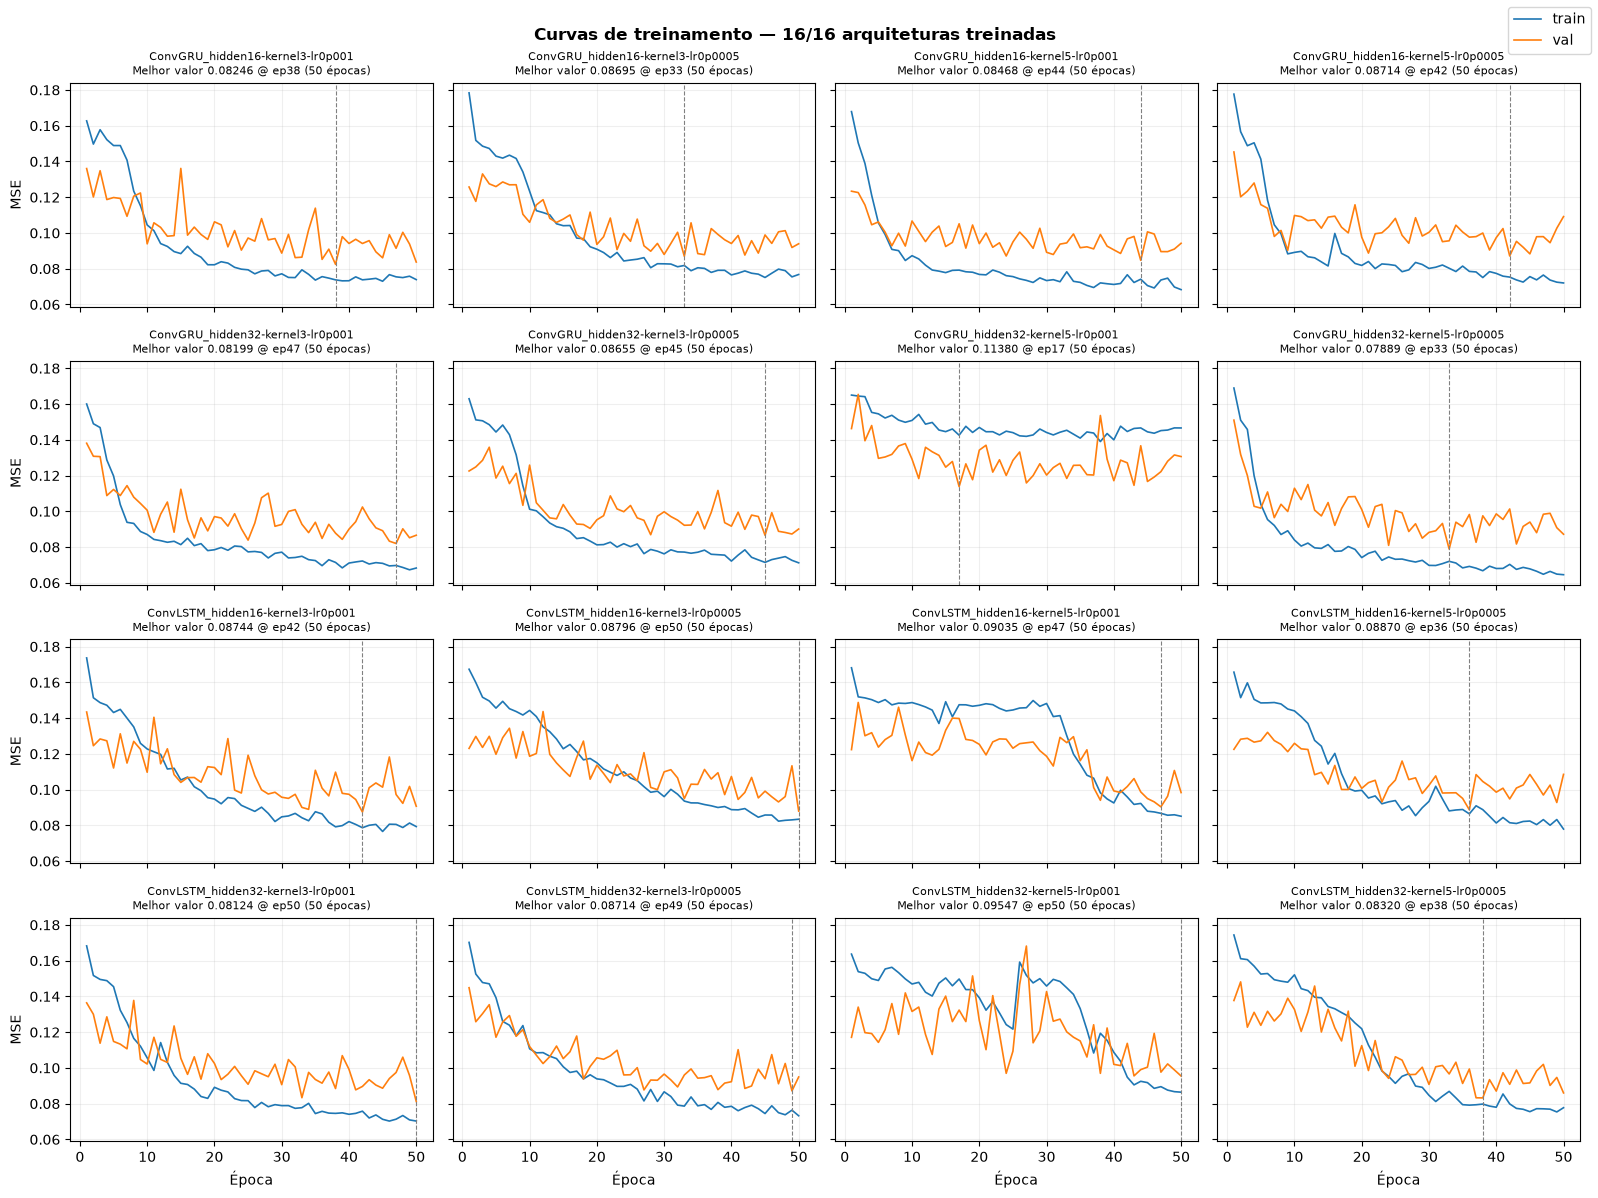

In [50]:
def plot_histories(ncols=4):
    
    runs = [
        f"{arch}_" + f"hidden{hidden}-" + f"kernel{kernel}-" + f"lr{lr}".replace(".", "p")
        for arch in ARCH
        for hidden in HIDDEN_CHANNELS
        for kernel in KERNEL_SIZE
        for lr in LEARNING_RATE
    ]
    
    nrows = -(-len(runs) // ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes).ravel()
    
    trained = 0
    
    for ax, run in zip(axes, runs):
        history = load_history(run, LOGS_DIR)
        
        if history is None:
            ax.set_title(run, fontsize=8, color="grey")
            ax.text(
                0.5, 0.5, "not trained yet",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=9, color="grey"
            )
            continue
        
        trained += 1
        epochs = history["epoch"] + 1
        
        ax.plot(epochs, history["train_loss"], label="train", linewidth=1.2)
        ax.plot(epochs, history["val_loss"], label="val", linewidth=1.2)
        
        best = history["val_loss"].idxmin()
        best_epoch = int(history.loc[best, "epoch"]) + 1
        ax.axvline(best_epoch, linestyle="--", linewidth=0.8, color="grey")
        
        ax.set_title(
            f"{run}\nMelhor valor {history['val_loss'].min():.5f} @ ep{best_epoch}"
            f" ({len(history)} épocas)",
            fontsize=8
        )
        ax.grid(alpha=0.2)
    
    for ax in axes[len(runs):]:
        ax.axis("off")
    
    for ax in axes[-ncols:]:
        ax.set_xlabel("Época")
    for ax in axes[::ncols]:
        ax.set_ylabel("MSE")
    
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")
    
    fig.suptitle(
        f"Curvas de treinamento — {trained}/{len(runs)} arquiteturas treinadas",
        fontweight="bold"
    )
    
    plt.tight_layout()
    plt.show()

plot_histories()

Função para puxar e pré-processar dados de teste. Novamente, busca de dados brutos pode ser ignorada se dados já estão presentes:

In [51]:
def fetch_test_data(skip_raw=True, skip_preproc=False):

    pipeline = DataPipeline(
        label_path="data/labels/test_2000_2024.tif",
        raw_path="data/raw_test/",
        preproc_path="data/preprocessed_test/",
        stats_path=TEST_STATS_PATH,
        year_start=YEAR_START,
        year_end=YEAR_END
    )
    if not skip_raw:
        pipeline.raw()
    if not skip_preproc:
        pipeline.preprocessed()
        pipeline.labels(outfile=f"data/labels/test_{YEAR_START}_{YEAR_END}_normalized.tif")
        
fetch_test_data()

2026-09-01 03:00:23,040 | INFO | src.data | Preprocessing file 2018-01.VH ...
2026-09-01 03:00:23,711 | INFO | src.data | Preprocessing file 2018-01.VV ...
2026-09-01 03:00:23,968 | INFO | src.data | Preprocessing file 2018-02.VH ...
2026-09-01 03:00:24,254 | INFO | src.data | Preprocessing file 2018-02.VV ...
2026-09-01 03:00:24,551 | INFO | src.data | Preprocessing file 2018-03.VH ...
2026-09-01 03:00:24,814 | INFO | src.data | Preprocessing file 2018-03.VV ...
2026-09-01 03:00:25,075 | INFO | src.data | Preprocessing file 2018-04.VH ...
2026-09-01 03:00:25,397 | INFO | src.data | Preprocessing file 2018-04.VV ...
2026-09-01 03:00:25,661 | INFO | src.data | Preprocessing file 2018-05.VH ...
2026-09-01 03:00:25,972 | INFO | src.data | Preprocessing file 2018-05.VV ...
2026-09-01 03:00:26,235 | INFO | src.data | Preprocessing file 2018-06.VH ...
2026-09-01 03:00:26,510 | INFO | src.data | Preprocessing file 2018-06.VV ...
2026-09-01 03:00:26,773 | INFO | src.data | Preprocessing file 2

Função para avaliar 

In [52]:
def evaluate(
    weights: list[str | Path],
    dataset: SARDataset,
    results_dir: str | Path
) -> list[dict]:
    
    results = []
    pattern = r"(?P<model>[^_]+)_hidden(?P<hidden>\d+)-kernel(?P<kernel>\d+)-lr(?P<lr>[\d]+p[\d]+)"
    
    results_dir = Path(results_dir)
    results_dir.mkdir(exist_ok=True)
    
    with rio.open(dataset.label_path) as src:
        labels = src.read(1)
    
    logger.info(f"Avaliando {len(weights)} checkpoints em {len(dataset)} amostras...")
    for w in weights:
        
        results_path = results_dir / f"{w.stem}.pkl"
        if results_path.exists():
            logger.warning(f"Resultados para {w.stem} já existem. Pulando...")
            continue
        
        match = re.fullmatch(pattern, w.stem)
        params = match.groupdict()
        
        if params["model"] == "ConvGRU":
            arch = ConvGRURegressor
        elif params["model"] == "ConvLSTM":
            arch = ConvLSTMRegressor
        else:
            raise ValueError("Arquitetura desconhecida...")
            
        model = load_weights(
            arch, w,
            input_channels=INPUT_CHANNELS,
            hidden_channels=int(params["hidden"]),
            kernel_size=int(params["kernel"]),
            head_channels=HEAD_CHANNELS
        )
        
        result = conv_rnn_predict(
            model=model,
            dataset=test_dataset,
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            batch_size=BATCH_SIZE
        )
        
        results.append(
            {
                "model": params["model"],
                "hidden": int(params["hidden"]),
                "kernel": int(params["kernel"]),
                "lr": float(params["lr"].replace("p", ".")),
                "array": result,
                "rmse": masked_rmse(result, labels),
                "mae": masked_mae(result, labels)
            }
        )
        logger.info(f"Avaliando {w.stem}: RMSE={results[-1]['rmse']:.5f}, MAE={results[-1]['mae']:.5f}")
    
        with open(results_path, "wb") as f:
            pkl.dump(results, f)

In [53]:
weight_list = sorted(list(WEIGHTS_DIR.iterdir()))
VAL_RESULTS_DIR = RESULTS_DIR / "validation"
VAL_RESULTS_DIR.parent.mkdir(exist_ok=True)

val_dataset = SARDataset(
    data_dir=DATA_DIR, 
    label_path=LABEL_PATH,
    stats_path=STATS_PATH,
    patch_size=PATCH_SIZE
)

val_results = evaluate(
    weight_list, 
    val_dataset,
    VAL_RESULTS_DIR
)

/tmp/ipykernel_62419/2442198749.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  labels = src.read(1)
2026-09-01 03:01:17,320 | INFO | __main__ | Avaliando 16 checkpoints em 182 amostras...
2026-09-01 03:01:17,321 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p0005 já existem. Pulando...
2026-09-01 03:01:17,322 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p001 já existem. Pulando...
2026-09-01 03:01:17,323 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p0005 já existem. Pulando...
2026-09-01 03:01:17,324 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p001 já existem. Pulando...
2026-09-01 03:01:17,325 | WARNING | __main__ | Resultados para ConvGRU_hidden32-kernel3-lr0p0005 já existem. Pulando...
2026-09-01 03:01:17,326 | WARNING | __main__ | Resultados para ConvGRU_h

In [54]:
weight_list = sorted(list(WEIGHTS_DIR.iterdir()))
TEST_RESULTS_DIR = RESULTS_DIR / "test"
TEST_RESULTS_DIR.parent.mkdir(exist_ok=True)

test_dataset = SARDataset(
    data_dir=TEST_DATA_DIR, 
    label_path=TEST_LABEL_PATH,
    stats_path=TEST_STATS_PATH,
    patch_size=PATCH_SIZE
)

test_results = evaluate(
    weight_list, 
    test_dataset,
    TEST_RESULTS_DIR
)

/tmp/ipykernel_62419/2442198749.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  labels = src.read(1)
2026-09-01 03:01:17,375 | INFO | __main__ | Avaliando 16 checkpoints em 182 amostras...
2026-09-01 03:01:17,376 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p0005 já existem. Pulando...
2026-09-01 03:01:17,377 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel3-lr0p001 já existem. Pulando...
2026-09-01 03:01:17,378 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p0005 já existem. Pulando...
2026-09-01 03:01:17,379 | WARNING | __main__ | Resultados para ConvGRU_hidden16-kernel5-lr0p001 já existem. Pulando...
2026-09-01 03:01:17,380 | WARNING | __main__ | Resultados para ConvGRU_hidden32-kernel3-lr0p0005 já existem. Pulando...
2026-09-01 03:01:17,380 | WARNING | __main__ | Resultados para ConvGRU_h